# Live Surface

Builds the IV surface from the same sample snapshot `02_iv_solver.ipynb` used, then
looks at where our solved IV disagrees with Yahoo's own. No internet needed.

In [2]:
import sys

sys.path.insert(0, "..")  # optionsengine lives one level up, next to notebooks/

import pandas as pd
import matplotlib.pyplot as plt
import plotly.io as pio
from optionsengine import config
from optionsengine.quotes import clean_quotes
from optionsengine.validation import add_our_iv, add_error, add_moneyness_bucket, mae_rmse, mae_rmse_by
from optionsengine.surface import add_log_moneyness, build_surface
from optionsengine.plotting import plot_surface, plot_smiles, plot_term_structure

# GitHub can't run the JS behind an interactive Plotly figure, so bake a static image
# instead. The real interactive version comes from scripts/live_surface.py.
pio.renderers.default = "png"

## Load, clean, solve

Same pipeline as `02_iv_solver.ipynb`: load the sample snapshot, clean it, solve
our own IV for each quote.

In [3]:
raw = pd.read_csv("../data/snapshots/sample_spx_20260827_1349.csv")
raw["asof"] = pd.to_datetime(raw["asof"])

quotes = clean_quotes(raw, weekly_root=config.ACTIVE.weekly_root,
                       monthly_root=config.ACTIVE.monthly_root,
                       am_hour=config.AM_SETTLEMENT_HOUR, pm_hour=config.PM_SETTLEMENT_HOUR,
                       r=config.r)
quotes = add_our_iv(quotes, config.r)
quotes = add_log_moneyness(quotes)
print(f"{len(quotes)} quotes solved")

5802 quotes solved


## The surface

One smile per expiry, interpolated with PCHIP onto a shared log-moneyness grid, then
stacked across expiries.

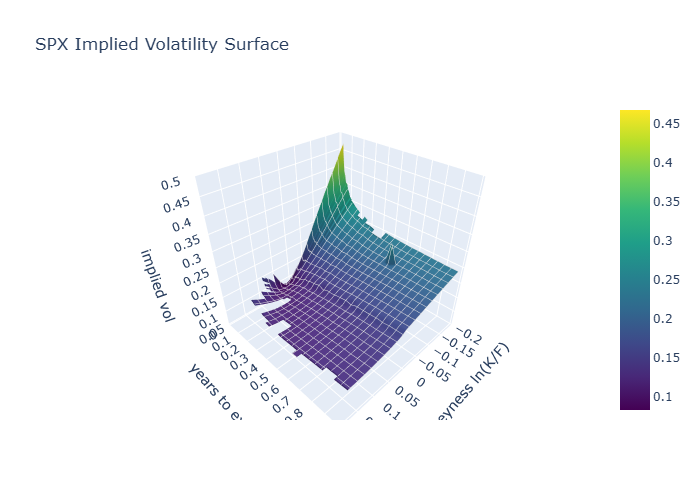

In [4]:
surface = build_surface(quotes, iv_column="iv_ours")
fig = plot_surface(surface, title=f"{config.ACTIVE_SYMBOL} Implied Volatility Surface")
fig.show()

## Smiles and term structure

A handful of individual smiles, and the at-the-money vol against time to expiry.

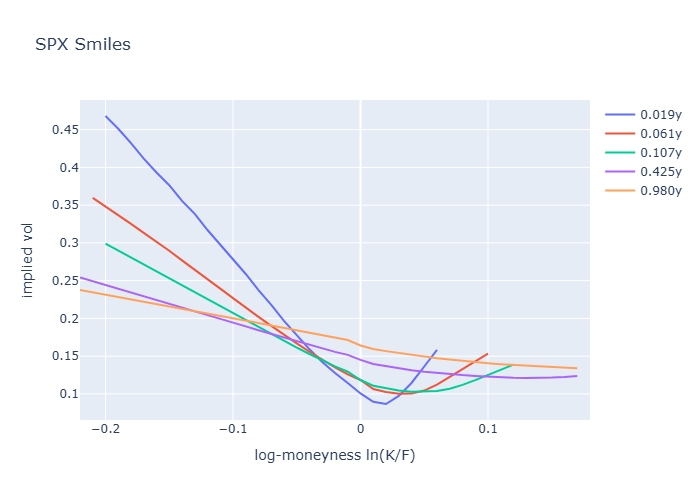

In [5]:
years = sorted(surface.index)
picks = [years[i] for i in (0, len(years) // 4, len(years) // 2, 3 * len(years) // 4, -1)]

fig = plot_smiles(surface, years_to_expiry=picks, title=f"{config.ACTIVE_SYMBOL} Smiles")
fig.show()

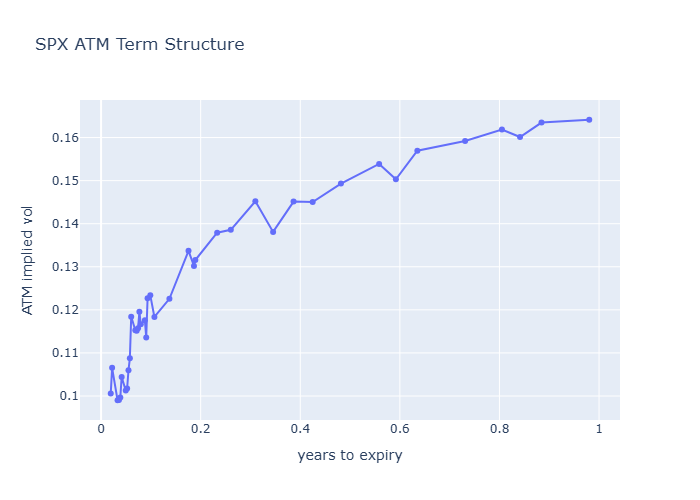

In [6]:
fig = plot_term_structure(surface, title=f"{config.ACTIVE_SYMBOL} ATM Term Structure")
fig.show()

## Checked against Yahoo

Not a clean test of the model alone: we don't know how Yahoo computes its own IV, and it
may reflect a slightly earlier price than the bid/ask sitting next to it in the same
response. Any gap could come from our model, from Yahoo's method, or from that timing
mismatch.

In [7]:
quotes = add_error(quotes)
quotes = add_moneyness_bucket(quotes)

mae, rmse = mae_rmse(quotes)
print(f"overall MAE  = {mae:.4f}")
print(f"overall RMSE = {rmse:.4f}")

overall MAE  = 0.0155
overall RMSE = 0.0185


## The error isn't simply "worse near the money" or "worse at the wings"

Grouping the error by moneyness bucket doesn't give either simple story. In this snapshot it rises through the put side, peaks just below the money, then drops on the call side before ticking back up at the far out-of-the-money call wing. Not a clean symmetric hump, but not monotonic either. The middle is worse than both ends put together.

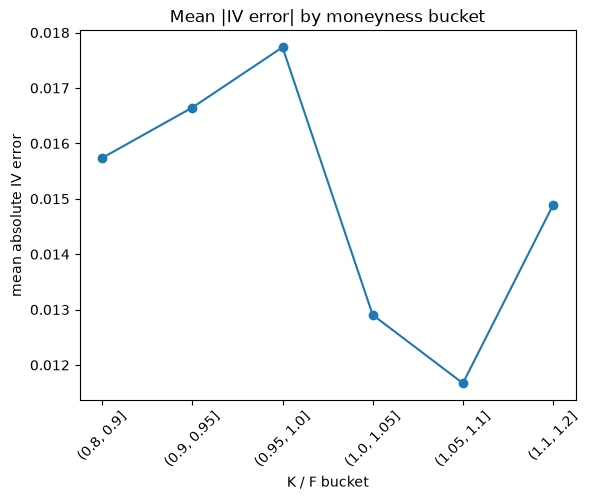

In [8]:
by_bucket = mae_rmse_by(quotes, "moneyness_bucket").sort_index()

fig, ax = plt.subplots()
ax.plot(by_bucket.index.astype(str), by_bucket["mae"], marker="o")
ax.set_title("Mean |IV error| by moneyness bucket")
ax.set_xlabel("K / F bucket")
ax.set_ylabel("mean absolute IV error")
plt.xticks(rotation=45)
plt.show()

## The real driver: a forward mismatch

A cleaner place to look than a bucket average: the exact strike where puts hand off to
calls. If both sides are solved consistently, IV should be roughly continuous there.

In [9]:
by_right = quotes.groupby("right")["iv_error"].mean()
print(by_right)

right
C   -0.012647
P    0.016750
Name: iv_error, dtype: float64


Yahoo jumps backwards at the money in 40/40 expiries
We do in 0/40 expiries


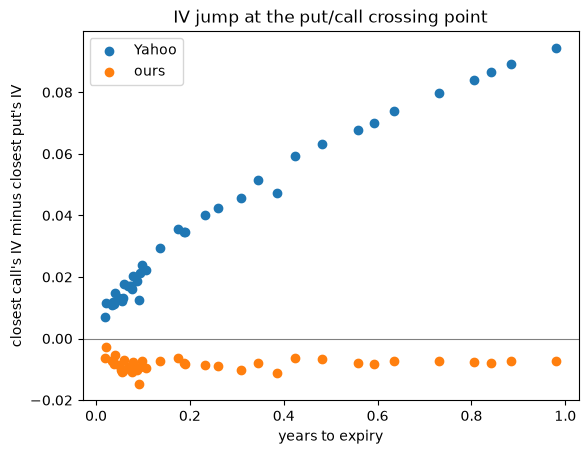

In [10]:
jumps = []
for years, group in quotes.groupby("years_to_expiry"):
    puts = group[group["right"] == "P"].sort_values("strike")
    calls = group[group["right"] == "C"].sort_values("strike")
    if puts.empty or calls.empty:
        continue
    jumps.append({
        "years": years,
        "jump_yahoo": calls.iloc[0]["implied_vol_yahoo"] - puts.iloc[-1]["implied_vol_yahoo"],
        "jump_ours": calls.iloc[0]["iv_ours"] - puts.iloc[-1]["iv_ours"],
    })
jumps = pd.DataFrame(jumps)
print(f"Yahoo jumps backwards at the money in {(jumps['jump_yahoo'] > 0).sum()}/{len(jumps)} expiries")
print(f"We do in {(jumps['jump_ours'] > 0).sum()}/{len(jumps)} expiries")

fig, ax = plt.subplots()
ax.scatter(jumps["years"], jumps["jump_yahoo"], label="Yahoo")
ax.scatter(jumps["years"], jumps["jump_ours"], label="ours")
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_title("IV jump at the put/call crossing point")
ax.set_xlabel("years to expiry")
ax.set_ylabel("closest call's IV minus closest put's IV")
ax.legend()
plt.show()

Our IV stays smooth through the money, which makes sense since both sides are solved
the same way. Yahoo's IV jumps backwards there every time, and the jump gets bigger
the further out the expiry is. That's not random noise. It's what happens when calls
and puts are priced against different forwards, and a dividend yield would cause
exactly this kind of gap, growing with time the way we see here.

## How much of it is dividends

This project assumes no dividends (`q = 0`). SPX actually pays out about 1.3% a year.
To see how much that matters, we re-solve using `r - q` instead of `r`. Lowering the
rate this way has the same effect as adding a dividend yield: it lowers the forward.

In [11]:
from optionsengine.implied_vol import implied_vol as _implied_vol

def solve_at_rate(row, rate):
    return _implied_vol(row["mid"], row["underlying_price"], row["strike"],
                         row["years_to_expiry"], rate, row["right"]).iv

for q in (0.0, 0.013, 0.04):
    iv_q = quotes.apply(lambda row: solve_at_rate(row, config.r - q), axis=1)
    mae_q = (iv_q - quotes["implied_vol_yahoo"]).abs().mean()
    print(f"q={q:.3f}  MAE={mae_q:.4f}")

q=0.000  MAE=0.0155
q=0.013  MAE=0.0110
q=0.040  MAE=0.0019


SPX's real dividend yield only closes about a third of the gap. To close it fully we'd
need an effective yield of about 4%, three times the real number. So dividends are
part of the story, but not all of it. The rest is probably Yahoo using a different
forward altogether, maybe one based on SPX futures, which bake in financing costs on
top of dividends. This doesn't change the model: `q = 0` is still the right choice
here (see the README). But it does explain most of the hump we saw earlier, since the
bucket edges split almost exactly into puts below 1.0 and calls above it.

## Next

That's the whole pipeline: fetch, clean, solve, build, plot. `scripts/live_surface.py`
runs the same steps live and redraws on demand.